# Testing multiple drivers

Just to keep my theory notebook from getting too complicated, I've built a separate notebook to test the code for handling multiple drivers. The two models for a 1x and 2x box should have exactly the same curves except for overall SPL.

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from speakerTheorySympy import *

## 1x12 and 2x12 ported boxes using Eminence 2512-ii

In [2]:
eminence_2512ii_driver = {
    # Thiele-Small parameters from Eminence DeltaLite 2512-ii driver
    # 'Znom': 8.0, # Nominal impedance, Ohms
    #'P_e': 250, # Rated power, Watts, we don't use this.
    'f_s': 53.1, # Resonant frequency, Hz
    w_s: sp.N(53.1*2*sp.pi), # Resonant angular frequency, Hz
    R_e: 5.28, # DC resistance, Ohms
    L_e: 0.31*1e-3, # Voice coil inductance, H
    Q_ms: 2.94, # Mechanical Q factor
    Q_es: 0.64, # Electrical Q factor
    V_as: 67.44*1e-3, # Compliance equivalent air volume, m^3
    'X_max': 4.9*1e-3, # Maximum linear excursion, m
    S_d: 519.5*1e-4, # Diaphragm area, m^2
    # Additional physical constants
    rho: 1.2, # Air density, kg/m^3
    c: 343, # Speed of sound, m/s
    # System parameters
    # 'P_in_rms': 100, # Input power, Watts
    R_ref: 1.0, # Reference distance for SPL calculation, m
    P_ref: 20e-6, # Reference sound pressure for SPL calculation, Pa
}

finish_driver_params(eminence_2512ii_driver)

emi_box_1 = {
    N_d: 1,
    V_box: 32*1e-3, # Box volume, liters converted to m^3
    f_port: 40,
    S_port: 21*3.5*1e-4, # Port area, cm*cm converted to m^2
    end_correct: 0.732,
    'Znom': 8,
    'P_in_rms': 100}

emi_system_1 = build_em_params(eminence_2512ii_driver, emi_box_1)
emi_system_1  = build_ported_params(emi_system_1, emi_box_1[f_port])

'''
The 2x example should have identical excursion, impedance, and port air speed
but 6 dB higher SPL due to 2x sensitivity and 2x input power.
'''
emi_box_2 = {
    N_d: 2,
    V_box: 64*1e-3, # Double the box volume
    f_port: 40, # Same port tuning
    S_port: 2*21*3.5*1e-4, # Double the port area
    end_correct: 0.732,
    'Znom': 4, # 2 drivers in parallel
    'P_in_rms': 200} # Double the total power, i.e., equal power per driver

emi_system_2 = build_em_params(eminence_2512ii_driver, emi_box_2)
emi_system_2  = build_ported_params(emi_system_2, emi_box_2[f_port])

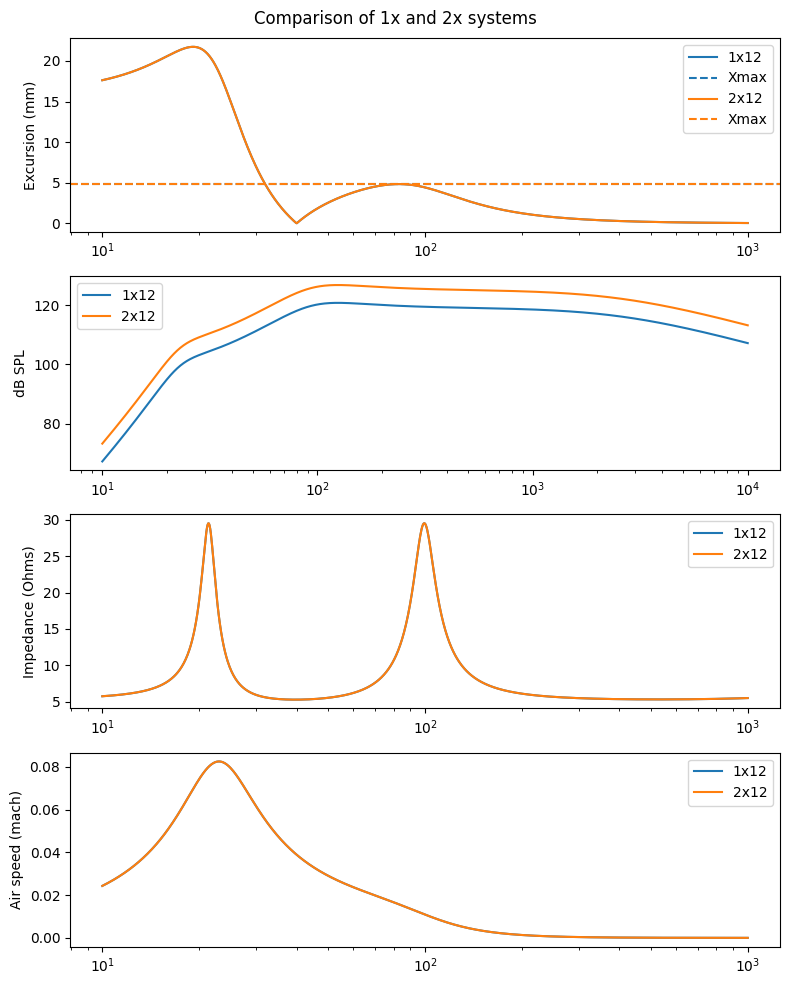

In [3]:
fig, axs = plt.subplots(4, figsize = (8, 10))
def plot_all(system, label):
    excursion_curve(system, axs[0], label = label)
    sensitivity_curve_ported(system, axs[1], label)
    impedance_curve(system, axs[2], label = label)
    airspeed_curve_ported(system, axs[3], label)

plot_all(emi_system_1, '1x12')
plot_all(emi_system_2, '2x12')
plt.suptitle('Comparison of 1x and 2x systems')
fig.tight_layout()

In [4]:
print('Did you remember to save first?')
!python3 -m jupyter nbconvert --to pdf ./Testing_multiple_drivers.ipynb

Did you remember to save first?
[NbConvertApp] Converting notebook ./Testing_multiple_drivers.ipynb to pdf
[NbConvertApp] Support files will be in Testing_multiple_drivers_files/
[NbConvertApp] Making directory ./Testing_multiple_drivers_files
[NbConvertApp] Writing 30030 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 121643 bytes to Testing_multiple_drivers.pdf
